In [1]:
import numpy as np

X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.rand(100,1)

In [2]:
X_b = np.c_[np.ones((100,1)), X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [3]:
theta_best

array([[4.61016999],
       [2.94535298]])

In [4]:
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)),X_new]
y_predict= X_new_b.dot(theta_best)
y_predict

array([[ 4.61016999],
       [10.50087596]])

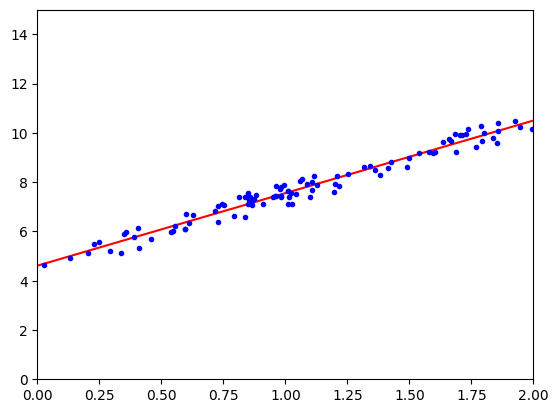

In [5]:
from matplotlib import pyplot as plt

plt.plot(X_new,y_predict, "r-")
plt.plot(X,y,"b.")
plt.axis([0,2,0,15])
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X,y)
lin_reg.intercept_, lin_reg.coef_

(array([4.61016999]), array([[2.94535298]]))

In [7]:
lin_reg.predict(X_new)

array([[ 4.61016999],
       [10.50087596]])

In [8]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b,y,rcond=1e-6)
theta_best_svd

array([[4.61016999],
       [2.94535298]])

In [9]:
np.linalg.pinv(X_b).dot(y)

array([[4.61016999],
       [2.94535298]])

In [10]:
eta = 0.1
n_ites = 1000
m = 100

theta = np.random.randn(2,1)

for iteration in range(n_ites):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

In [11]:
theta

array([[4.61016999],
       [2.94535298]])

In [12]:
import numpy as np
import matplotlib.pyplot as plt

X_train = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])
w_tmp = np.array([1, 1])


def compute_cost_logistic_regression(x, w, b, y):
    cost = 0
    m, n = x.shape
    for i in range(m):
        f_wb = np.dot(x[i], w) + b
        sigmoid = 1 / (1 + np.exp(-f_wb))
        cost += -y[i] * np.log(sigmoid) - (1 - y[i]) * np.log(1 - sigmoid)
    cost /= m
    print(cost)

compute_cost_logistic_regression(X_train, w_tmp, -3, y_train)

0.36686678640551745


In [13]:
import numpy as np

x = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1])
w = np.array([0.1, 0.1])
b = 1

In [14]:
def gradient_descent(x, y, w, b):
    m, n = x.shape
    learning_rate = 0.1
    for epoch in range(10000):
        cost = 0
        dw_j = np.zeros(n)
        dw_b = 0
        for i in range(m):
            f_wb = np.dot(x[i], w) + b
            sigmoid = 1 / (1 + np.exp(-f_wb))
            err = sigmoid - y[i]
            for j in range(n):
                current_x = x[i, j]
                dw_j[j] = dw_j[j] + err * current_x

            dw_b += err
            cost += -y[i] * np.log(sigmoid) - (1 - y[i]) * np.log(1 - sigmoid)

        dw_b /= m
        dw_j /= m
        cost /= m

        w = w - learning_rate * dw_j
        b = b - learning_rate * dw_b
        if epoch % 100 == 0:
            print(f"Iteration: {epoch}, Weight: {w}, Bias: {b}, Cost: {cost}")

gradient_descent(x, y, w, b)


Iteration: 0, Weight: [0.08189232 0.07846115], Bias: 0.9717330417424377, Cost: 0.845213659110049
Iteration: 100, Weight: [0.38917554 0.12603206], Bias: -0.3127428069764401, Cost: 0.6101345428412777
Iteration: 200, Weight: [0.72648011 0.44228086], Bias: -1.2873709045026525, Cost: 0.4932054006418842
Iteration: 300, Weight: [1.00412168 0.73013915], Bias: -2.117779326798543, Cost: 0.40789139274618597
Iteration: 400, Weight: [1.24440086 0.98167096], Bias: -2.8327595605221667, Cost: 0.3444292307313262
Iteration: 500, Weight: [1.45567153 1.20197427], Bias: -3.4554633878253, Cost: 0.29617248269864155
Iteration: 600, Weight: [1.64335474 1.39669254], Bias: -4.003980654162746, Cost: 0.25865839909710603
Iteration: 700, Weight: [1.81158594 1.57046743], Bias: -4.492254305223914, Cost: 0.2288876772864222
Iteration: 800, Weight: [1.96361592 1.72694662], Bias: -4.9310276606339105, Cost: 0.20481805895095104
Iteration: 900, Weight: [2.10202101 1.86898662], Bias: -5.328635801124855, Cost: 0.18503321023401

In [15]:
import numpy as np
import pandas as pd

data = {
    'Feature_1': [0, 1, 0, 2, 1, 0, 2, 2],  # Encoded categorical variable
    'Feature_2': [1, 2, 1, 2, 3, 1, 3, 2],  # Numerical
    'Feature_3': [10.5, 20.3, 30.1, 25.5, 15.7, 22.1, 19.8, 10.3],  # Numerical
    'Target': [0, 1, 0, 1, 1, 0, 1, 0]  # Binary target
}

df = pd.DataFrame(data)

X = np.array(df[['Feature_1', 'Feature_2', 'Feature_3']])
y = np.array(df['Target'])

W = np.array([
    [0.5, -0.3, 1.2],  # Weights for neuron 1
    [0.1, -0.6, 0.8],  # Weights for neuron 2
    [-0.4, 0.7, -0.5],  # Weights for neuron 3
    [0.9, -0.2, 0.3],  # Weights for neuron 4
    [0.6, 0.4, -0.1]  # Weights for neuron 5
])

b = np.array([0.1, 0.5, 1, 3, 5])


def nn_hidden_layer(X, y, W, b, units):
    m, n = X.shape
    a1 = []
    for unit in range(units):
        list = []
        for i in range(m):
            f_x = np.dot(X[i], W[unit]) + b[unit]
            g_z = 1 / (1 + np.exp(-f_x))
            list.append(g_z)
        a1.append(list)
    activation = np.array(a1)
    activation = activation.T
    print(activation)


Z = np.matmul(X, W.T)
Z_with_bias = Z + b
Z_with_bias = 1 / (1 + np.exp(-Z_with_bias))
print(Z_with_bias)

nn_hidden_layer(X, y, W, b, 5)

[[9.99995881e-01 9.99751545e-01 2.79225738e-02 9.97400932e-01
  9.87257651e-01]
 [1.00000000e+00 9.99999839e-01 2.88652016e-04 9.99931595e-01
  9.87506814e-01]
 [1.00000000e+00 1.00000000e+00 1.59282467e-06 9.99992717e-01
  9.16061568e-01]
 [1.00000000e+00 9.99999998e-01 1.43750804e-05 9.99994155e-01
  9.88456248e-01]
 [9.99999991e-01 9.99988348e-01 5.76596556e-03 9.99667986e-01
  9.94674982e-01]
 [1.00000000e+00 9.99999977e-01 8.69578568e-05 9.99919727e-01
  9.60456220e-01]
 [1.00000000e+00 9.99999603e-01 5.00201107e-04 9.99960533e-01
  9.95592367e-01]
 [9.99997400e-01 9.99565118e-01 2.79225738e-02 9.99441669e-01
  9.97452266e-01]]
[[9.99995881e-01 9.99751545e-01 2.79225738e-02 9.97400932e-01
  9.87257651e-01]
 [1.00000000e+00 9.99999839e-01 2.88652016e-04 9.99931595e-01
  9.87506814e-01]
 [1.00000000e+00 1.00000000e+00 1.59282467e-06 9.99992717e-01
  9.16061568e-01]
 [1.00000000e+00 9.99999998e-01 1.43750804e-05 9.99994155e-01
  9.88456248e-01]
 [9.99999991e-01 9.99988348e-01 5.76596

In [16]:
##Stochatic Gradient Descent 
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t+ t1)

theta = np.random.randn(2,1)
theta

array([[1.38888801],
       [0.13441845]])

In [17]:
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.rand(100,1)
m = 100
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

In [18]:
theta

array([[ 7.737924 ],
       [-0.4906835]])

In [19]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(max_iter=1000,tol=1e-3, penalty=None,eta0=0.1)
sgd.fit(X,y.ravel())

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [20]:
sgd.intercept_, sgd.coef_

(array([4.52150199]), array([2.99820833]))

In [21]:
m = 100
X = 6 * np.random.rand(m,1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m,1)

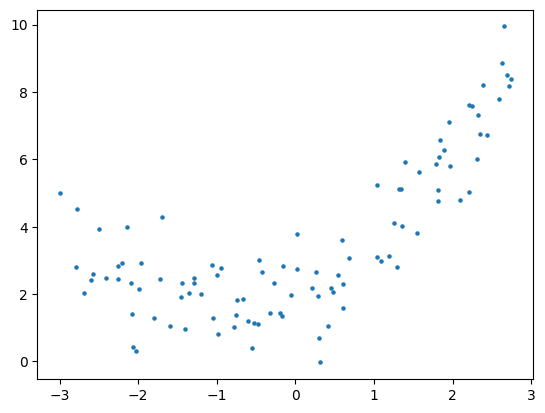

In [22]:
plt.scatter(X,y,s=5)
plt.show()

In [23]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-2.5813966])

In [24]:
X_poly[0]

array([-2.5813966 ,  6.66360841])

In [25]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly,y)
lin_reg.intercept_, lin_reg.coef_

(array([1.98951517]), array([[0.95182511, 0.54282023]]))

In [26]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model,X,y):
    X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2)
    train_errors,val_errors = [],[]
    for m in range(1,len(X_train)):
        model.fit(X_train[:m],y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m],y_train_predict))
        val_errors.append(mean_squared_error(y_val,y_val_predict))

    plt.plot(np.sqrt(train_errors),"r-+",linewidth=2,label="train")
    plt.plot(np.sqrt(val_errors),"b-",linewidth=3,label="val")
    plt.ylim(0, 5)

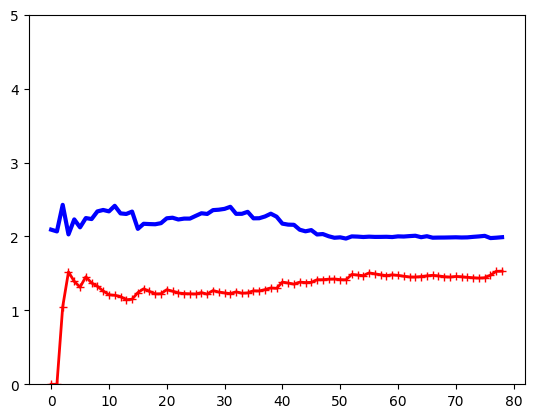

In [27]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg,X,y)

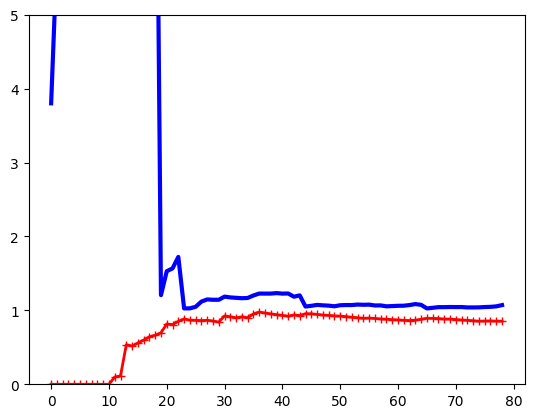

In [28]:
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
    ("poly_features",PolynomialFeatures(degree=10,include_bias=False)),
    ("lin_reg",LinearRegression()),
])
plot_learning_curves(polynomial_regression,X,y)

In [ ]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1,solver="cholesky")
ridge_reg.fit(X,y)
ridge_reg.predict